# Radial Basis Nearest Neighbors (RBNN)

## Classificação da base Iris e regressão da base Abalone

**Disciplina:** Aprendizado Supervisionado  
**Integrantes:** Lucas Cordeiro Raw; Gabbriel Nagano
_______________________________________________

## 1. Bibliotecas

São usadas bibliotecas apenas para manipulação dos dados, separação treino/teste, padronização, métricas e gráficos. O RBNN em si é implementado nas próximas células.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

sns.set_theme(style="whitegrid")
np.set_printoptions(precision=4, suppress=True)

## 2. Implementação do RBNN

Para deixar a implementação mais simples, foram criadas três funções:

- `gaussiana`: calcula o peso de cada distância.
- `classificar`: soma os pesos de cada classe e escolhe a maior soma.
- `regredir`: calcula a média ponderada dos valores de treino.

O `sigma` é passado como parâmetro nas funções. Antes de calcular os pesos, a menor distância ao quadrado é subtraída das demais. Assim, a amostra mais próxima sempre fica com peso 1 e evitamos que todos os pesos se tornem zero quando o sigma é muito pequeno.

In [ ]:
def gaussiana(dist, sigma):
    # Calcula o peso usando a função gaussiana
    gauss = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(dist ** 2) / (2 * sigma ** 2))
    return gauss


def classificar(X_train, y_train, X_test, sigma):
    X_train = np.array(X_train, dtype=float)
    X_test = np.array(X_test, dtype=float)
    y_train = np.array(y_train)

    classes = np.unique(y_train)
    predicoes = []

    for amostra in X_test:
        # Distância euclidiana
        dist = np.sqrt(np.sum((X_train - amostra) ** 2, axis=1))
        pesos = gaussiana(dist, sigma)

        votos = []
        for classe in classes:
            soma = pesos[y_train == classe].sum()
            votos.append(soma)

        if np.max(pesos) == 0:
          raise ValueError(f"Todos os pesos zeraram (sigma={sigma}). Verifique a escala dos dados.")

        classe_predita = classes[np.argmax(votos)]
        predicoes.append(classe_predita)

    return np.array(predicoes)


def regredir(X_train, y_train, X_test, sigma):
    X_train = np.array(X_train, dtype=float)
    X_test = np.array(X_test, dtype=float)
    y_train = np.array(y_train, dtype=float)

    predicoes = []

    for amostra in X_test:
        dist = np.sqrt(
            np.sum((X_train - amostra) ** 2, axis=1)
        )

        pesos = gaussiana(dist, sigma)
        soma_pesos = np.sum(pesos)

        if soma_pesos == 0:
            predicoes.append(np.nan)
        else:
            previsao = np.sum(pesos * y_train) / soma_pesos
            predicoes.append(previsao)

    return np.array(predicoes)


def testar_sigmas(X_train, y_train, X_test, y_test, sigmas):
    resultados = []

    y_test = np.array(y_test, dtype=float)

    for sigma in sigmas:
        pred = regredir(
            X_train,
            y_train,
            X_test,
            sigma
        )

        validos = ~np.isnan(pred)

        qtd_nulos = np.isnan(pred).sum()
        perc_nulos = qtd_nulos / len(pred) * 100

        if validos.sum() > 1:
            mae = mean_absolute_error(y_test[validos],pred[validos])

            rmse = np.sqrt(mean_squared_error(y_test[validos],pred[validos]))

            r2 = r2_score(y_test[validos],pred[validos])

        else:
            mae = np.nan
            rmse = np.nan
            r2 = np.nan

        resultados.append({
            "Sigma": sigma,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Nulos": qtd_nulos,
            "Nulos (%)": perc_nulos
        })

    return pd.DataFrame(resultados)


### Teste simples das funções

Antes de usar as bases, foi feito um teste pequeno para conferir se as funções retornam uma classificação e uma previsão.

In [ ]:
X_ex = np.array([[0.0], [1.0], [2.0], [3.0]])
X_novo = np.array([[0.2], [2.8]])

y_classe = np.array(["A", "A", "B", "B"])
y_num = np.array([0.0, 1.0, 4.0, 9.0])

print("Classificação:", classificar(X_ex, y_classe, X_novo, sigma=0.5))
print("Regressão:", regredir(X_ex, y_num, X_novo, sigma=0.5).round(3))

Classificação: ['A' 'B']
Regressão: [0.236 7.834]


## 3. Carregamento das bases da UCI

- **Iris:** possui 150 amostras, quatro atributos e três classes.
- **Abalone:** possui 4.177 amostras. A coluna que será prevista é `Rings`.

As duas bases foram carregadas diretamente da UCI.

In [ ]:
url_iris = "https://archive.ics.uci.edu/static/public/53/data.csv"
url_abalone = "https://archive.ics.uci.edu/static/public/1/data.csv"

iris = pd.read_csv(url_iris)
abalone = pd.read_csv(url_abalone)

print("Tamanho da Iris:", iris.shape)
print("Tamanho da Abalone:", abalone.shape)
print("Valores ausentes na Iris:", iris.isna().sum().sum())
print("Valores ausentes na Abalone:", abalone.isna().sum().sum())
print("\nQuantidade por classe da Iris:")
print(iris["class"].value_counts())

Tamanho da Iris: (150, 5)
Tamanho da Abalone: (4177, 9)
Valores ausentes na Iris: 0
Valores ausentes na Abalone: 0

Quantidade por classe da Iris:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 4. Classificação - Iris

A base foi dividida em 70% para treino e 30% para teste. Foi usada a divisão estratificada para manter a quantidade das três classes equilibrada. Como o algoritmo trabalha com distâncias, os dados foram padronizados.

Nesta primeira aplicação foi usado $\sigma=0{,}25$.

In [ ]:
Xi = iris.drop(columns="class")
yi = iris["class"]

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    Xi, yi, test_size=0.30, random_state=42, stratify=yi
)

escala_i = StandardScaler()
Xi_train = escala_i.fit_transform(Xi_train)
Xi_test = escala_i.transform(Xi_test)

sigma_i = 0.25
pred_i = classificar(Xi_train, yi_train, Xi_test, sigma_i)

acc = accuracy_score(yi_test, pred_i)
print(f"Acurácia: {acc:.4f} ({acc * 100:.2f}%)\n")
print(classification_report(yi_test, pred_i, zero_division=0))

Acurácia: 0.9333 (93.33%)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.83      1.00      0.91        15
 Iris-virginica       1.00      0.80      0.89        15

       accuracy                           0.93        45
      macro avg       0.94      0.93      0.93        45
   weighted avg       0.94      0.93      0.93        45



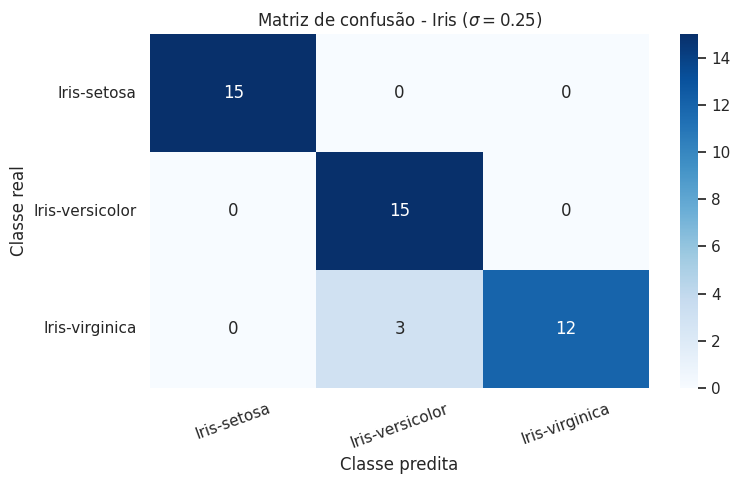

In [ ]:
#matriz confusão iris
classes = np.unique(yi)
matriz = confusion_matrix(yi_test, pred_i, labels=classes)

plt.figure(figsize=(8, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)
plt.title(f"Matriz de confusão - Iris ($\\sigma={sigma_i}$)")
plt.xlabel("Classe predita")
plt.ylabel("Classe real")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Resultado da Iris

O modelo acertou **93,33%** das amostras de teste. Todas as Setosas e Versicolors foram classificadas corretamente. Três amostras de Virginica foram classificadas como Versicolor.

Isso faz sentido porque Setosa é bem separada das outras duas classes, enquanto Versicolor e Virginica possuem características mais parecidas.

# 5. Predição - Abalone

In [ ]:
#visualização da base Abalone
abalone

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64


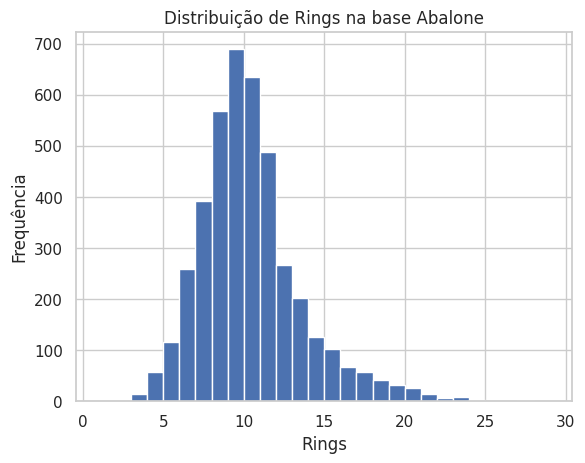

In [ ]:
#distribuição da variável alvo

print(abalone["Rings"].describe())
abalone["Rings"].hist(bins=28)
plt.xlabel("Rings")
plt.ylabel("Frequência")
plt.title("Distribuição de Rings na base Abalone")
plt.show()

In [ ]:
#preparando abalone
xa = abalone.drop(columns = 'Rings')
ya = abalone['Rings']

xa = pd.get_dummies(xa, ['Sex'], dtype=float)

xa_train, xa_test, ya_train, ya_test = train_test_split(xa, ya, test_size = 0.3, random_state = 42)

escala_a = StandardScaler()
xa_train = escala_a.fit_transform(xa_train)
xa_test = escala_a.transform(xa_test)

sigma_a = 1
pred_a = regredir(xa_train, ya_train, xa_test, sigma_a)

mae_a = mean_absolute_error(ya_test, pred_a)
rmse_a = np.sqrt(mean_squared_error(ya_test, pred_a))
r2_a = r2_score(ya_test, pred_a)

print(f"MAE:  {mae_a:.4f}")
print(f"RMSE: {rmse_a:.4f}")
print(f"R²:   {r2_a:.4f}")


MAE:  1.7153
RMSE: 2.4281
R²:   0.4194


In [ ]:
comparacao = pd.DataFrame({
    "Rings_real": ya_test.values,
    "Rings_previsto": pred_a.round(2),
    "Erro": (pred_a - ya_test.values).round(2),
})

print("Primeiras 15 amostras do teste:")
print(comparacao.head(15).to_string(index=False))

print("\nEstatísticas do erro:")
print(comparacao["Erro"].describe().round(3))

Primeiras 15 amostras do teste:
 Rings_real  Rings_previsto   Erro
          9           11.04   2.04
          8           10.67   2.67
         16           11.42  -4.58
          9           11.20   2.20
         14           10.34  -3.66
         11            8.80  -2.20
          7            8.79   1.79
          6            9.89   3.89
          7            7.00  -0.00
         10           10.80   0.80
         22           11.01 -10.99
          7            6.92  -0.08
         15           10.84  -4.16
          9            7.17  -1.83
          8            8.65   0.65

Estatísticas do erro:
count    1254.000
mean       -0.017
std         2.429
min       -11.900
25%        -0.740
50%         0.565
75%         1.520
max         5.170
Name: Erro, dtype: float64


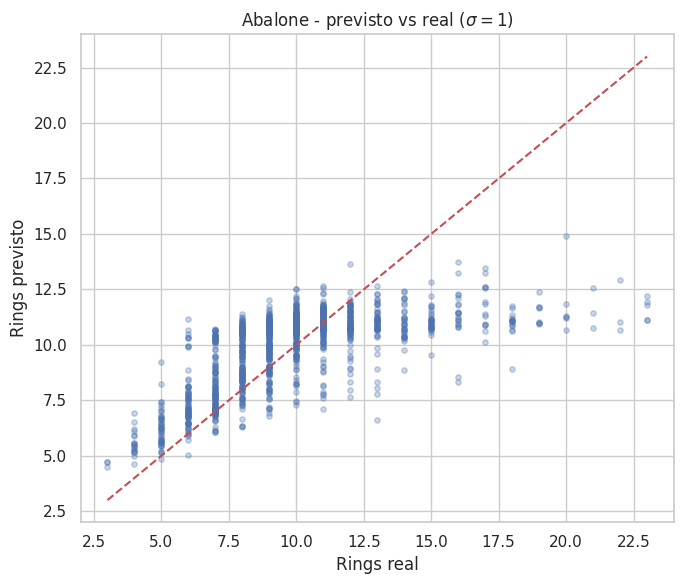

In [ ]:
#Plot com o valor inicial de sigma = 1 (somente para o treinamento da base)

plt.figure(figsize=(7, 6))
plt.scatter(ya_test, pred_a, alpha=0.3, s=15)
plt.plot([ya_test.min(), ya_test.max()], [ya_test.min(), ya_test.max()], "r--")
plt.xlabel("Rings real")
plt.ylabel("Rings previsto")
plt.title(f"Abalone - previsto vs real ($\\sigma={sigma_a}$)")
plt.tight_layout()
plt.show()

# 6. Comparação de Sigmas - Abalone

Para determinar o melhor sigma foi utilizada a métrica RMSE, que penaliza mais fortemente erros concentrados em poucas amostras dentro da base. Isso é relevante pois a distribuição de Rings é assimétrica: metade das amostras está entre 8 e 11 anéis, mas os valores chegam a 29. Como as amostras com muitos anéis são poucas, o MAE as dilui no conjunto e fica pouco sensível ao que acontece nessa faixa, enquanto o RMSE dá peso desproporcional a esses erros

In [ ]:
#comparando sigmas
sigmas = [0.01, 0.10, 0.25, 1, 100] #sigmas escolhidos

resultados_sigma = testar_sigmas(
    xa_train,
    ya_train,
    xa_test,
    ya_test,
    sigmas
)

resultados_sigma.round(4)

,Sigma,MAE,RMSE,R2,Nulos,Nulos (%)
0,0.01,1.8428,2.6504,0.1782,249,19.8565
1,0.10,1.7722,2.6151,0.3271,1,0.0797
2,0.25,1.5532,2.2522,0.5005,0,0.0000
3,1.00,1.7153,2.4281,0.4194,0,0.0000
4,100.00,2.3592,3.1903,-0.0023,0,0.0000


In [ ]:
resultados_validos = resultados_sigma[
    (resultados_sigma['Nulos']==0)&
    (resultados_sigma['RMSE'].notna())
]

melhor_linha = resultados_validos.loc[
    resultados_validos['RMSE'].idxmin()
]

melhor_sigma = melhor_linha['Sigma']

print("Melhor sigma:", melhor_sigma)
print("MAE:", round(melhor_linha["MAE"], 4))
print("RMSE:", round(melhor_linha["RMSE"], 4))

print("R²:", round(melhor_linha["R2"], 4))

Melhor sigma: 0.25
MAE: 1.5532
RMSE: 2.2522
R²: 0.5005


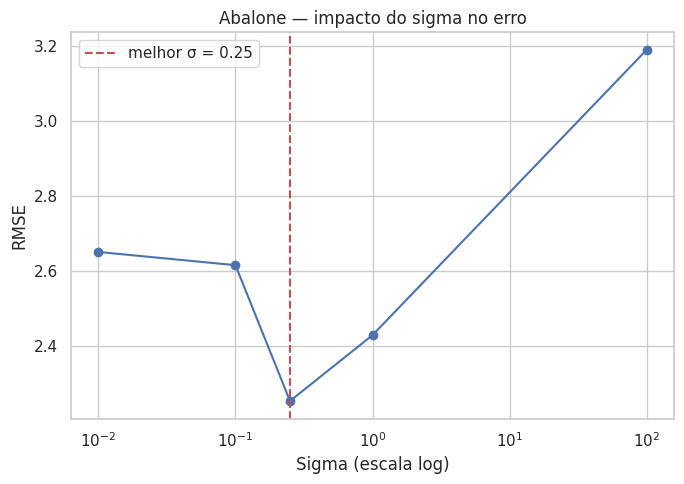

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(resultados_sigma["Sigma"], resultados_sigma["RMSE"], "o-")
plt.xscale("log")
plt.xlabel("Sigma (escala log)")
plt.ylabel("RMSE")
plt.title("Abalone — impacto do sigma no erro")
plt.axvline(melhor_sigma, color="r", ls="--", label=f"melhor σ = {melhor_sigma}")
plt.legend()
plt.tight_layout()
plt.show()

Com o sigma = 100, os pesos dos vizinhos ficam muito parecidos entre si e fazem com que a média ponderada se torne igual à média global de Rings no treino, o que faz o modelo sempre prever o mesmo valor e ignorar os atributos, sendo comprovado pelo valor de 3,19 do RMSE e R² = -0,0023. Enquanto isso, no sigma = 0,01 parte dos dados se tornaram nulos por terem pesos muito próximos de zero, o que não o torna comparável ao resto.

In [ ]:
#a.f abalone
sigma_a = melhor_sigma

pred_a = regredir(
    xa_train,
    ya_train,
    xa_test,
    sigma_a
)

mae_a = mean_absolute_error(
    ya_test,
    pred_a
)

rmse_a = np.sqrt(
    mean_squared_error(
        ya_test,
        pred_a
    )
)

r2_a = r2_score(
    ya_test,
    pred_a
)

print(f"Sigma escolhido: {sigma_a}")
print(f"MAE:  {mae_a:.4f}")
print(f"RMSE: {rmse_a:.4f}")
print(f"R²:   {r2_a:.4f}")

Sigma escolhido: 0.25
MAE:  1.5532
RMSE: 2.2522
R²:   0.5005


In [ ]:
#comparacao real e previsto


comparacao = pd.DataFrame({
    "Rings_real": ya_test.values,
    "Rings_previsto": pred_a.round(2),
    "Erro": (
        pred_a - ya_test.values
    ).round(2)
})

print("Primeiras 15 amostras do teste:")

print(
    comparacao
    .head(15)
    .to_string(index=False)
)

print("\nEstatísticas do erro:")

print(
    comparacao["Erro"]
    .describe()
    .round(3)
)

Primeiras 15 amostras do teste:
 Rings_real  Rings_previsto   Erro
          9           10.86   1.86
          8            9.58   1.58
         16           14.19  -1.81
          9           10.78   1.78
         14           11.82  -2.18
         11            9.03  -1.97
          7            8.81   1.81
          6            8.63   2.63
          7            6.90  -0.10
         10           10.37   0.37
         22           11.75 -10.25
          7            6.91  -0.09
         15           11.80  -3.20
          9            7.08  -1.92
          8            8.51   0.51

Estatísticas do erro:
count    1254.000
mean       -0.048
std         2.252
min       -11.950
25%        -0.818
50%         0.310
75%         1.190
max        10.410
Name: Erro, dtype: float64


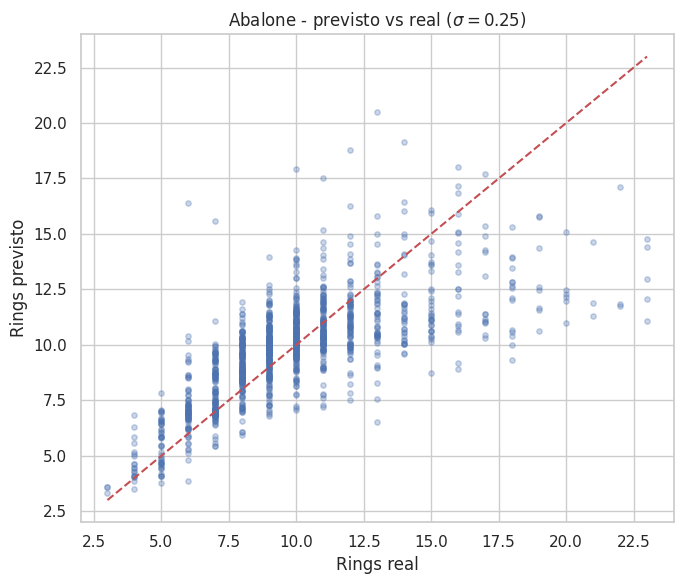

In [ ]:
#valores reais e previstos

plt.figure(figsize=(7, 6))

plt.scatter(
    ya_test,
    pred_a,
    alpha=0.3,
    s=15
)

plt.plot(
    [ya_test.min(), ya_test.max()],
    [ya_test.min(), ya_test.max()],
    "r--"
)

plt.xlabel("Rings real")
plt.ylabel("Rings previsto")

plt.title(
    f"Abalone - previsto vs real "
    f"($\\sigma={sigma_a}$)"
)

plt.tight_layout()
plt.show()